In [23]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import math
import glob
import re
sns.set(style='whitegrid')

In [24]:
wid_exp = [(512, 4, 220), (768, 4, 0), (1024, 4, 0), (512, 8, 350), (768, 8, 0), (512, 16, 0), (768, 16, 650)]
#wid_exp = [(512, 8, 350), (768, 8, 0), (512, 16, 0), (768, 16, 650)]
lrs = [0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128, 0.256]
seeds = [1]
depth = 14

time = '20251006_041813'

In [25]:
results_val = {}
results_tr = {}
for lr in lrs:
    for width, num_exp, _ in wid_exp:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                        results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_cccc/out_20251006_041813/width512_depth14_experts4_active1_seed1_lr0.002_alpha1.0/log.csv, val_loss achieved 3.841417789459229
average training loss for last 50 steps: 3.839219570159912

result found for ../run_data/mutransfer_lr_cccc/out_20251006_041813/width768_depth14_experts4_active1_seed1_lr0.002_alpha1.0/log.csv, val_loss achieved 3.719472646713257
average training loss for last 50 steps: 3.7194881439208975

result found for ../run_data/mutransfer_lr_cccc/out_20251006_041813/width1024_depth14_experts4_active1_seed1_lr0.002_alpha1.0/log.csv, val_loss achieved 3.657797336578369
average training loss for last 50 steps: 3.6570003032684326

result found for ../run_data/mutransfer_lr_cccc/out_20251006_041813/width512_depth14_experts8_active2_seed1_lr0.002_alpha1.0/log.csv, val_loss achieved 3.723347425460816
average training loss for last 50 steps: 3.724775552749634

result found for ../run_data/mutransfer_lr_cccc/out_20251006_041813/width768

In [26]:
def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    
    # Average over seeds for each configuration and lr
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        
        # Average MSEs for each lr
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    
    # Count total experiments
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    
    # Print summary
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    
    # Plot each configuration
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                num_act = int(n_exp // 4)
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.3, 4.5)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results (no router learning) ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results


def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}

    return result

def find_job_file(base_path, time_dir, job_prefix):

    # Construct the search path
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}_*.log")

    # Find matching files
    matches = glob.glob(search_pattern)

    if not matches:
        return None, None

    # Take the first match if multiple exist
    full_path = matches[0]
    filename = os.path.basename(full_path)

    # Parse filename: job_0008_gpu7_w256_exp4_lr4.52e-02_seed0.log
    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
    match = re.match(pattern, filename)

    if not match:
        return filename, None

    params = {
        'width': int(match.group(1)),
        'num_exp': int(match.group(2)),
        'lr': float(match.group(3)),
        'seed': int(match.group(4))
    }

    return filename, params

Total experiments: 48

Results by configuration:
  n=4, width=512: 8 valid lr points
    Best: lr=3.200e-02, MSE=3.750965
  n=4, width=768: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.627945
  n=4, width=1024: 8 valid lr points
    Best: lr=1.600e-02, MSE=3.566914
  n=8, width=512: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.676636
  n=8, width=768: 8 valid lr points
    Best: lr=1.600e-02, MSE=3.566653
  n=16, width=512: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.610771



Plot saved as: plots/hp_transfer_plot_20251009_043638.png


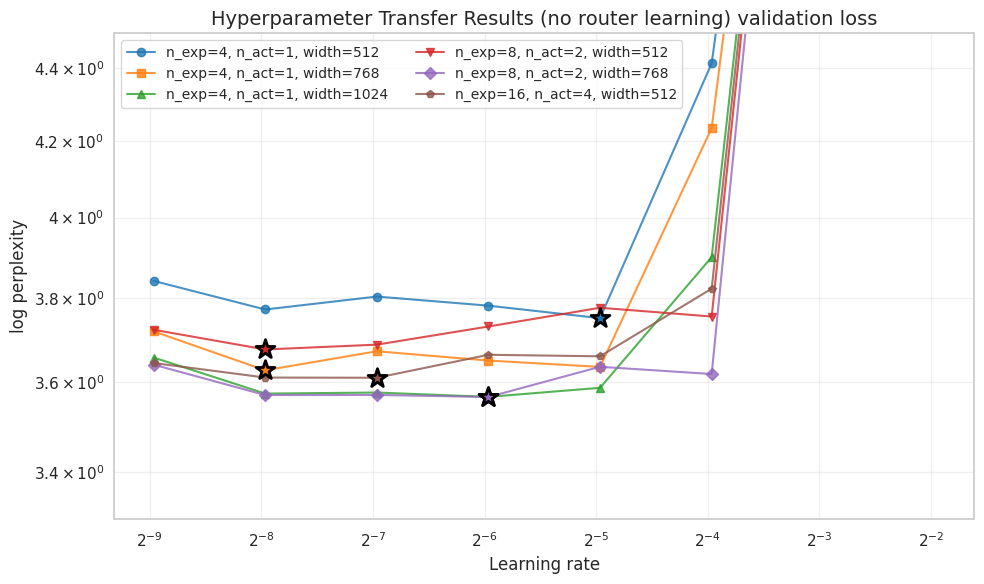

{(4, 512): [(0.002, np.float64(3.841417789459229)),
  (0.004, np.float64(3.771801710128784)),
  (0.008, np.float64(3.803109407424927)),
  (0.016, np.float64(3.781031847000122)),
  (0.032, np.float64(3.750964641571045)),
  (0.064, np.float64(4.414854049682617)),
  (0.128, np.float64(7.412708759307861)),
  (0.256, np.float64(7.426301002502441))],
 (4, 768): [(0.002, np.float64(3.719472646713257)),
  (0.004, np.float64(3.6279447078704834)),
  (0.008, np.float64(3.6724448204040527)),
  (0.016, np.float64(3.650678873062134)),
  (0.032, np.float64(3.6359338760375977)),
  (0.064, np.float64(4.235793590545654)),
  (0.128, np.float64(7.42124605178833)),
  (0.256, np.float64(7.41892671585083))],
 (4, 1024): [(0.002, np.float64(3.657797336578369)),
  (0.004, np.float64(3.5743963718414307)),
  (0.008, np.float64(3.576791286468506)),
  (0.016, np.float64(3.566913604736328)),
  (0.032, np.float64(3.5876238346099854)),
  (0.064, np.float64(3.900237560272217)),
  (0.128, np.float64(7.410383701324463))

In [27]:
plot_results(results_val, title = "validation loss")

In [28]:
results_val

{(512, 4, 1, 1, 0.002): np.float64(3.841417789459229),
 (768, 4, 1, 1, 0.002): np.float64(3.719472646713257),
 (1024, 4, 1, 1, 0.002): np.float64(3.657797336578369),
 (512, 8, 2, 1, 0.002): np.float64(3.723347425460816),
 (768, 8, 2, 1, 0.002): np.float64(3.641191005706787),
 (512, 16, 4, 1, 0.002): np.float64(3.644941329956055),
 (512, 4, 1, 1, 0.004): np.float64(3.771801710128784),
 (768, 4, 1, 1, 0.004): np.float64(3.6279447078704834),
 (1024, 4, 1, 1, 0.004): np.float64(3.5743963718414307),
 (512, 8, 2, 1, 0.004): np.float64(3.676635980606079),
 (768, 8, 2, 1, 0.004): np.float64(3.571018934249878),
 (512, 16, 4, 1, 0.004): np.float64(3.6112117767333984),
 (512, 4, 1, 1, 0.008): np.float64(3.803109407424927),
 (768, 4, 1, 1, 0.008): np.float64(3.6724448204040527),
 (1024, 4, 1, 1, 0.008): np.float64(3.576791286468506),
 (512, 8, 2, 1, 0.008): np.float64(3.687963485717773),
 (768, 8, 2, 1, 0.008): np.float64(3.5713343620300293),
 (512, 16, 4, 1, 0.008): np.float64(3.61077094078064),


In [29]:
result_complete = {}
for job_idx in range(60):
    job_idstr = f"job_{job_idx:04d}"
    print()
    x, y = find_job_file("../std_out/mutransfer_lr_owt", "20250924_044616", job_idstr)
    file_name = "../std_out/mutransfer_lr_owt/20250924_044616/stdout/"+x
    if os.path.exists(file_name):
                    loss_dict = parse_validation_loss(file_name)
                    width, num_exp, num_act, seed, lr = y['width'], y['num_exp'], y['num_exp']//4 , y['seed'], y['lr']
                    result_complete[(width, num_exp, num_act, seed, lr)] = loss_dict
                    print(f"job {job_idx} found, width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr}, loss_dict {loss_dict}")
    else:
                    print(f"File {file_name} does not exist, check your path")

TypeError: can only concatenate str (not "NoneType") to str

never reached 1001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0452
never reached 1001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.004
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.00566
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.008
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.0113
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.016
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.0227
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.032
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.0452
never reached 1001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.064
Total experiments: 58

Results by configuration:
  n=4, width=256: 8 valid lr points
    Best: lr=1.130e-02,

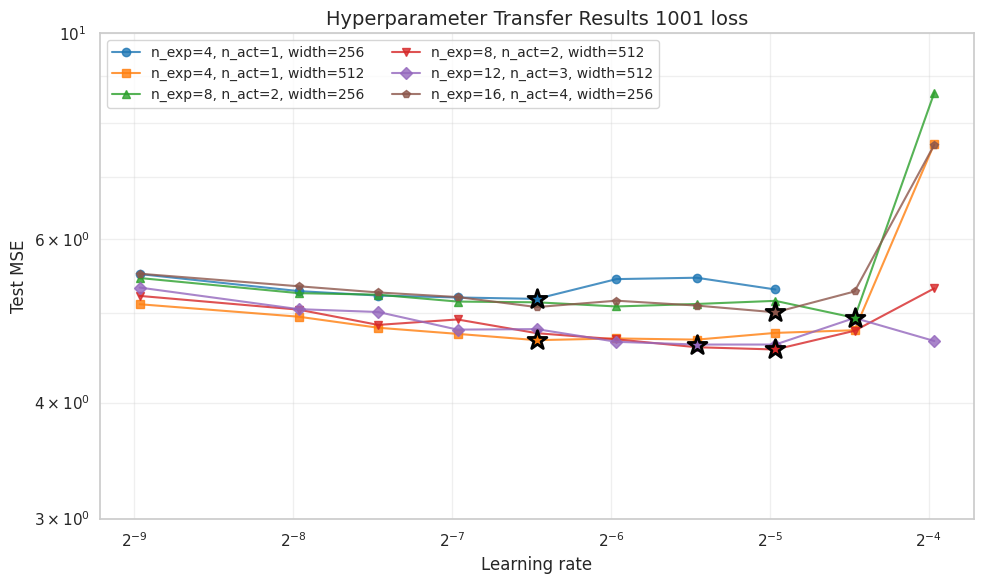

{(4, 256): [(0.002, np.float64(5.5027)),
  (0.004, np.float64(5.2752)),
  (0.00566, np.float64(5.2174)),
  (0.008, np.float64(5.1923)),
  (0.0113, np.float64(5.1742)),
  (0.016, np.float64(5.4344)),
  (0.0227, np.float64(5.4531)),
  (0.032, np.float64(5.2965))],
 (8, 256): [(0.002, np.float64(5.449)),
  (0.004, np.float64(5.2483)),
  (0.00566, np.float64(5.228)),
  (0.008, np.float64(5.1397)),
  (0.0113, np.float64(5.1304)),
  (0.016, np.float64(5.0777)),
  (0.0227, np.float64(5.1092)),
  (0.032, np.float64(5.1489)),
  (0.0452, np.float64(4.937)),
  (0.064, np.float64(8.6288))],
 (4, 512): [(0.002, np.float64(5.1058)),
  (0.004, np.float64(4.9504)),
  (0.00566, np.float64(4.8166)),
  (0.008, np.float64(4.7439)),
  (0.0113, np.float64(4.6704)),
  (0.016, np.float64(4.6903)),
  (0.0227, np.float64(4.6766)),
  (0.032, np.float64(4.7553)),
  (0.0452, np.float64(4.7869)),
  (0.064, np.float64(7.6013))],
 (8, 512): [(0.002, np.float64(5.2126)),
  (0.004, np.float64(5.0379)),
  (0.00566, np.f

In [ ]:
result_1001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lr_short)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_1001[(width, num_exp, num_act, seed, lr_short[i])] = result_complete[(width, num_exp, num_act, seed, lr_short[i])][1001]
                except:
                    print(f"never reached 1001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr_short[i]}")
plot_results(result_1001, title = "1001 loss")


never reached 2001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0452
never reached 2001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.004
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.00566
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.008
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.0113
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.016
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.0227
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.032
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.0452
never reached 2001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.064
Total experiments: 58

Results by configuration:
  n=4, width=256: 8 valid lr points
    Best: lr=8.000e-03,


Plot saved as: plots/hp_transfer_plot_20250926_024541.png


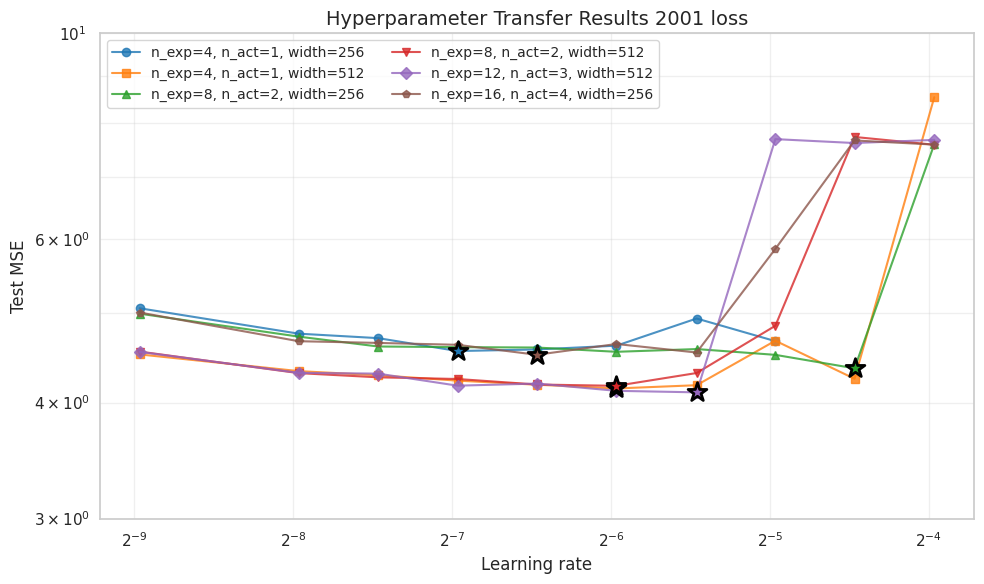

{(4, 256): [(0.002, np.float64(5.0551)),
  (0.004, np.float64(4.7464)),
  (0.00566, np.float64(4.6939)),
  (0.008, np.float64(4.546)),
  (0.0113, np.float64(4.564)),
  (0.016, np.float64(4.607)),
  (0.0227, np.float64(4.9282)),
  (0.032, np.float64(4.659))],
 (8, 256): [(0.002, np.float64(4.9875)),
  (0.004, np.float64(4.7117)),
  (0.00566, np.float64(4.5975)),
  (0.008, np.float64(4.5904)),
  (0.0113, np.float64(4.5858)),
  (0.016, np.float64(4.5374)),
  (0.0227, np.float64(4.5684)),
  (0.032, np.float64(4.5032)),
  (0.0452, np.float64(4.3553)),
  (0.064, np.float64(7.5936))],
 (4, 512): [(0.002, np.float64(4.5081)),
  (0.004, np.float64(4.3252)),
  (0.00566, np.float64(4.2811)),
  (0.008, np.float64(4.2241)),
  (0.0113, np.float64(4.1818)),
  (0.016, np.float64(4.143)),
  (0.0227, np.float64(4.1765)),
  (0.032, np.float64(4.6639)),
  (0.0452, np.float64(4.2439)),
  (0.064, np.float64(8.5341))],
 (8, 512): [(0.002, np.float64(4.5399)),
  (0.004, np.float64(4.3036)),
  (0.00566, np.flo

In [ ]:
result_2001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lr_short)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_2001[(width, num_exp, num_act, seed, lr_short[i])] = result_complete[(width, num_exp, num_act, seed, lr_short[i])][2001]
                except:
                    print(f"never reached 2001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr_short[i]}")
plot_results(result_2001, title = "2001 loss")

never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.004
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.00566
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.008
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0113
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.016
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0227
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.032
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0452
never reached 5001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 5001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 5001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.004
never reached 5001 for width 1024, num_exp 4, num_act 1, seed 0, lr 0.00566
never reached 5001 for width 1024, num_ex

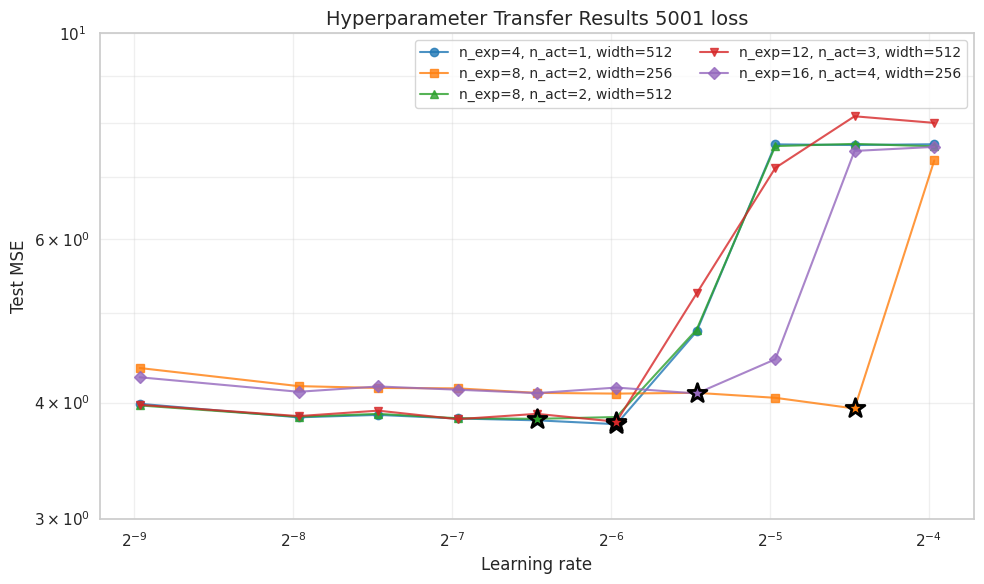

{(8, 256): [(0.002, np.float64(4.3585)),
  (0.004, np.float64(4.167)),
  (0.00566, np.float64(4.1482)),
  (0.008, np.float64(4.144)),
  (0.0113, np.float64(4.0976)),
  (0.016, np.float64(4.0904)),
  (0.0227, np.float64(4.0982)),
  (0.032, np.float64(4.0479)),
  (0.0452, np.float64(3.942)),
  (0.064, np.float64(7.2949))],
 (4, 512): [(0.002, np.float64(3.9884)),
  (0.004, np.float64(3.8565)),
  (0.00566, np.float64(3.8799)),
  (0.008, np.float64(3.8454)),
  (0.0113, np.float64(3.828)),
  (0.016, np.float64(3.7916)),
  (0.0227, np.float64(4.772)),
  (0.032, np.float64(7.5918)),
  (0.0452, np.float64(7.5795)),
  (0.064, np.float64(7.5942))],
 (8, 512): [(0.002, np.float64(3.972)),
  (0.004, np.float64(3.862)),
  (0.00566, np.float64(3.8897)),
  (0.008, np.float64(3.8479)),
  (0.0113, np.float64(3.8424)),
  (0.016, np.float64(3.8593)),
  (0.0227, np.float64(4.7939)),
  (0.032, np.float64(7.5599)),
  (0.0452, np.float64(7.6009)),
  (0.064, np.float64(7.5555))],
 (16, 256): [(0.002, np.float

In [ ]:
result_5001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lr_short)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_5001[(width, num_exp, num_act, seed, lr_short[i])] = result_complete[(width, num_exp, num_act, seed, lr_short[i])][5001]
                except:
                    print(f"never reached 5001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr_short[i]}")
plot_results(result_5001, title = "5001 loss")

never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.004
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.00566
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.008
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0113
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.016
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0227
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.032
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.0452
never reached 8001 for width 256, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 8001 for width 256, num_exp 8, num_act 2, seed 0, lr 0.002
never reached 8001 for width 256, num_exp 8, num_act 2, seed 0, lr 0.004
never reached 8001 for width 256, num_exp 8, num_act 2, seed 0, lr 0.00566
never reached 8001 for width 256, num_exp 8,


Plot saved as: plots/hp_transfer_plot_20250926_024542.png


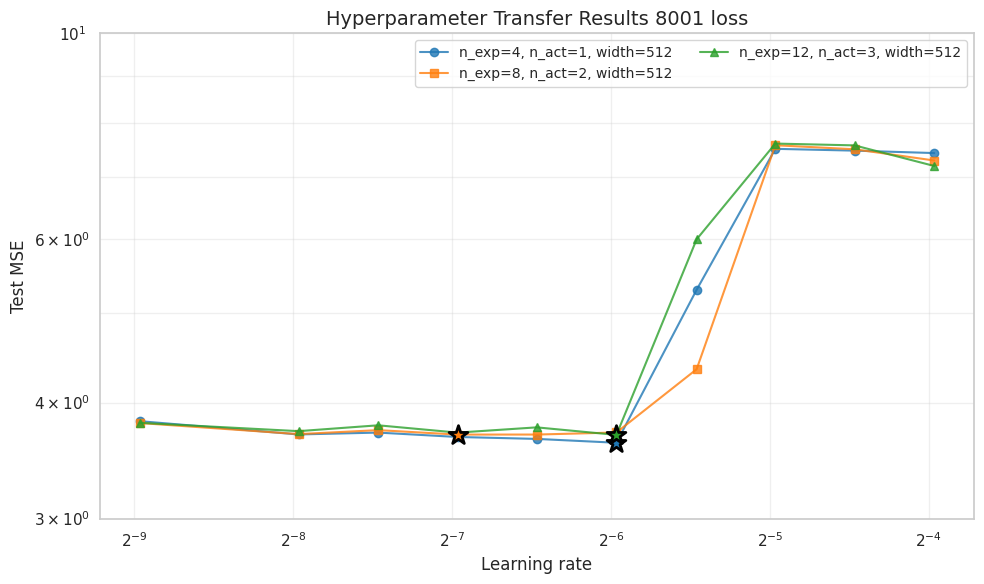

{(4, 512): [(0.002, np.float64(3.82)),
  (0.004, np.float64(3.6961)),
  (0.00566, np.float64(3.7133)),
  (0.008, np.float64(3.6731)),
  (0.0113, np.float64(3.6555)),
  (0.016, np.float64(3.6208)),
  (0.0227, np.float64(5.2922)),
  (0.032, np.float64(7.5081)),
  (0.0452, np.float64(7.4747)),
  (0.064, np.float64(7.4298))],
 (8, 512): [(0.002, np.float64(3.8025)),
  (0.004, np.float64(3.6993)),
  (0.00566, np.float64(3.7359)),
  (0.008, np.float64(3.6949)),
  (0.0113, np.float64(3.6952)),
  (0.016, np.float64(3.7142)),
  (0.0227, np.float64(4.3453)),
  (0.032, np.float64(7.5755)),
  (0.0452, np.float64(7.5)),
  (0.064, np.float64(7.2939))],
 (12, 512): [(0.002, np.float64(3.8042)),
  (0.004, np.float64(3.7265)),
  (0.00566, np.float64(3.781)),
  (0.008, np.float64(3.713)),
  (0.0113, np.float64(3.7617)),
  (0.016, np.float64(3.6919)),
  (0.0227, np.float64(5.9979)),
  (0.032, np.float64(7.6069)),
  (0.0452, np.float64(7.5727)),
  (0.064, np.float64(7.1954))]}

In [ ]:
result_8001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lr_short)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_8001[(width, num_exp, num_act, seed, lr_short[i])] = result_complete[(width, num_exp, num_act, seed, lr_short[i])][8001]
                except:
                    print(f"never reached 8001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr_short[i]}")
plot_results(result_8001, title = "8001 loss")